#Kavish Nag
#24070126085
#AIML B1


In [44]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import TruncatedSVD

In [45]:
df = pd.read_csv("/content/personality_datasert.csv")
df

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert
...,...,...,...,...,...,...,...,...
2895,3.0,No,7.0,6.0,No,6.0,6.0,Extrovert
2896,3.0,No,8.0,3.0,No,14.0,9.0,Extrovert
2897,4.0,Yes,1.0,1.0,Yes,4.0,0.0,Introvert
2898,11.0,Yes,1.0,3.0,Yes,2.0,0.0,Introvert


In [46]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)

X = pd.get_dummies(X, drop_first=True)

/tmp/ipython-input-362/949763217.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=original_personality_labels, palette='viridis')


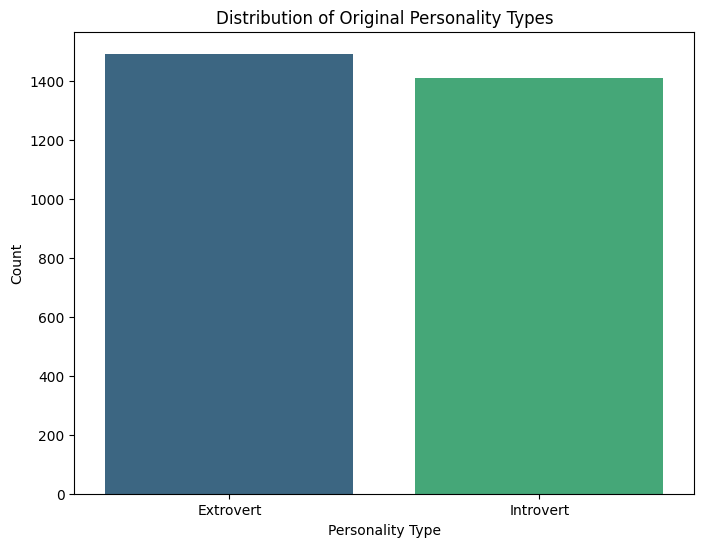

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

original_personality_labels = le.inverse_transform(y)
plt.figure(figsize=(8, 6))
sns.countplot(x=original_personality_labels, palette='viridis')
plt.title('Distribution of Original Personality Types')
plt.xlabel('Personality Type')
plt.ylabel('Count')
plt.show()

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#WITHOUT SVD


In [50]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

accuracy_log= accuracy_score(y_test, y_pred)

print("Accuracy without SVD:", accuracy_log)

Accuracy without SVD: 0.9189655172413793


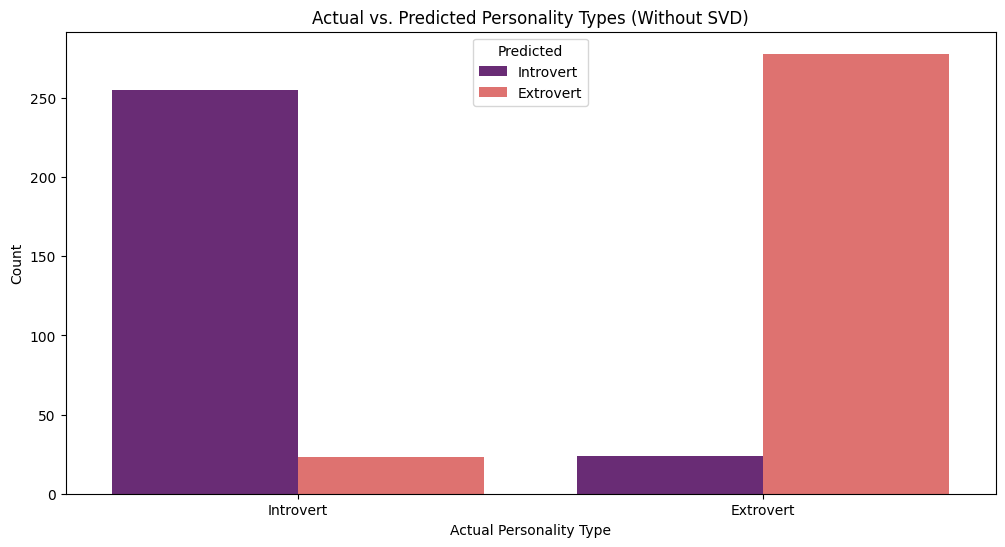

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert numerical predictions back to original labels
actual_labels = le.inverse_transform(y_test)
predicted_labels = le.inverse_transform(y_pred)

# Create a DataFrame for easier plotting
comparison_df = pd.DataFrame({'Actual': actual_labels, 'Predicted': predicted_labels})

plt.figure(figsize=(12, 6))
sns.countplot(x='Actual', hue='Predicted', data=comparison_df, palette='magma')
plt.title('Actual vs. Predicted Personality Types (Without SVD)')
plt.xlabel('Actual Personality Type')
plt.ylabel('Count')
plt.legend(title='Predicted')
plt.show()

#with SVD


In [52]:
svd = TruncatedSVD(n_components=7, random_state=42)

X_train_svd = svd.fit_transform(X_train_scaled)
X_test_svd = svd.transform(X_test_scaled)

log_model_svd = LogisticRegression(max_iter=1000)

log_model_svd.fit(X_train_svd, y_train)

y_pred_svd = log_model_svd.predict(X_test_svd)

accuracy_with_svd = accuracy_score(y_test, y_pred_svd)

print("Accuracy with SVD:", accuracy_with_svd)

Accuracy with SVD: 0.9189655172413793


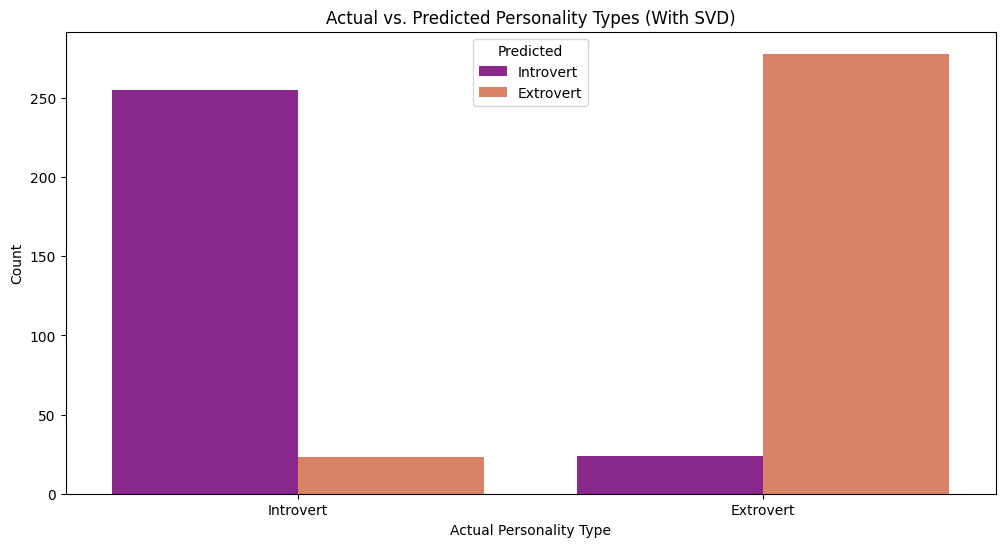

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

predicted_labels_svd = le.inverse_transform(y_pred_svd)
comparison_svd_df = pd.DataFrame({'Actual': actual_labels, 'Predicted': predicted_labels_svd})

plt.figure(figsize=(12, 6))
sns.countplot(x='Actual', hue='Predicted', data=comparison_svd_df, palette='plasma')
plt.title('Actual vs. Predicted Personality Types (With SVD)')
plt.xlabel('Actual Personality Type')
plt.ylabel('Count')
plt.legend(title='Predicted')
plt.show()